# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Text Cleaning**
* **Feature Engineering**
    * Tokenization and Vocabulary Building
    * Tokenization
    * N-gram Tokens Sequence Generation
    * Sequences Padding
    * Train and Validation Split
* **Model Training**
    * Model Architecture, Model Building, and Model Training (TensorFlow)
    * Training History Visualization
    * Model Validation (Perplexity)
* **Model Evaluation**
    * Perplexity, ROUGE-L, ROUGE-S, ROUGE-SU
    * Inference Test
* **Conclusion**
* **References**

# Introduction

Text generation is a fundamental application of Natural Language Processing (NLP), enabling machines to produce coherent, human-like text. The project focuses on constructing a text generation model utilizing Long Short-Term Memory (LSTM) networks, a specialized type of Recurrent Neural Network (RNN) inherently suited for sequential data analysis.

A specific dataset of essays is utilized for model training. This dataset is diverse, comprising essays written by human students alongside those generated by a language model (Gemini Pro). The data includes crucial metadata for development, such as the text content, classification labels (student or LLM-generated), prompt names, source models, and a boolean flag ($\text{RDizzl3\_seven}$).

The scope of the project covers the entire machine learning pipeline: from initial data preprocessing and deep model construction to final quantitative assessment. This provides a comprehensive reference for building and evaluating an LSTM-based system for textual generation.

# Objective

The primary objective involves developing an LSTM model with the capability to generate coherent and contextually relevant text sequences based on given prompts.

Specifically, the project goals include:

- Data Preparation: Preprocessing a diverse dataset of essays to prepare the sequential data for model consumption.
- Model Architecture: Building and training a deep LSTM architecture, incorporating bidirectional layers to effectively capture long-range sequential dependencies in the text.
- Evaluation: Assessing the generative capabilities of the model using standard metrics, including Perplexity and ROUGE scores, to quantify the quality of the generated text.
- Demonstration: Demonstrating the model's capacity to produce meaningful text sequences and comparing the generated outputs against reference texts from the original dataset.

Achievement of these goals will establish a robust text generation system capable of learning from diverse essay styles and producing high-quality textual output.

# Pipeline Overview

The pipeline for this text generation project consists of several key stages:

- Data Loading and Exploration: Load the dataset, sample a subset for efficiency, and visualize key characteristics like word frequency and sentence length.
- Preprocessing: Clean the text, tokenize it into sentences, build a vocabulary, and generate N-gram sequences for training.
- Model Building: Construct a deep LSTM model with bidirectional layers, embedding, dropout, and layer normalization.
- Model Training: Train the model with optimized hyperparameters, using early stopping and learning rate scheduling.
- Model Evaluation: Assess the model using perplexity and ROUGE metrics (ROUGE-L, ROUGE-S, ROUGE-SU) on a test set.
- Text Generation: Generate sample texts from prompts and compare them to reference texts.
- Visualization and Analysis: Visualize training metrics and analyze generated text quality.

This structured approach ensures a systematic development process, addressing both technical and practical aspects of text generation.

# Data dictionary

This dataset, created through the advanced capabilities of Google's flagship model Gemini-Pro, is made up of 3500 distinct essays. The average length of each text was selected based on the handwritten student essays featured in the **[LLM Detect AI Generated Text Competition](https://www.kaggle.com/competitions/llm-detect-ai-generated-text/data)**.

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">text</td>
    <td class="tg-7zrl">The essay created by each prompt</td>
    <td class="tg-7zrl">Text/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">label</td>
    <td class="tg-7zrl">Indicating whether the essay originated from a student (0) or was generated by a Language Model (LLM) (1)</td>
    <td class="tg-7zrl">Numeric/Binary</td>
  </tr>
  <tr>
    <td class="tg-7zrl">prompt_name</td>
    <td class="tg-7zrl">Represents which of the seven prompts was used during generation of an essay</td>
    <td class="tg-7zrl">Categorical/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">source</td>
    <td class="tg-7zrl">The used model during text generation (gemini_pro)</td>
    <td class="tg-7zrl">Categorical/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">RDizzl3_seven</td>
    <td class="tg-7zrl">Boolean flag</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/etiennekaiser/gemini-pro-llm-daigt-dataset)**

# Approach

**Preprocessing Pipeline Approach**

The preprocessing pipeline transforms raw essay text into a format suitable for LSTM training.

- Data Loading and Sampling: The dataset (train_essays_v1.csv) is loaded, and a 2% sample (approximately 70 essays) is drawn. This sampling strategy is employed to manage computational resources while preserving data representativeness.
- Text Cleaning: A dedicated cleaning function is applied to the text. This process standardizes the format by removing punctuation, converting text to lowercase, eliminating URLs, HTML tags, newlines, words containing digits, and non-ASCII characters.
- Sentence Tokenization: NLTK’s `sent_tokenize` utility is used to segment the cleaned essays into individual sentences. This results in 1,333 training sentences and 361 test sentences.
- Tokenization and Vocabulary Building: The Keras Tokenizer is utilized to convert the sentences into numerical token sequences. The vocabulary is capped at 5,500 words, including special tokens for start-of-sequence ($\langle SOS \rangle$), end-of-sequence ($\langle EOS \rangle$), and out-of-vocabulary ($\langle OOV \rangle$). The resulting effective vocabulary size is 3,425, with the remainder reserved for padding.
- N-gram Sequence Generation: N-gram sequences for next-word prediction are created by applying a sliding window over each sentence. This process yields 31,324 training sequences and 7,963 test sequences.
- Padding: Sequences are padded to a fixed length (56 for training, 55 for model input) using padding tokens. This is necessary to achieve uniform input dimensions for the LSTM model. The final token is designated as the prediction label, and all preceding tokens serve as predictors.
- Data Splitting: The training data is segmented into an 80% training set (25,059 sequences) and a 20% validation set (6,265 sequences). The validation set is used to monitor model performance and prevent overfitting during the training phase.

This comprehensive preprocessing methodology ensures the data is clean, tokenized, and precisely structured for effective training of the LSTM network.

**Model Training Approach**

The model is structured for next-word prediction, leveraging a deep, bidirectional LSTM architecture to handle sequential dependencies inherent in the text.

**Architecture**

The model architecture is designed with sequential context capture in mind:

- Input Layer: Accepts token sequences with a fixed length of 55 (derived from the maximum sequence length minus the prediction token).
- Embedding Layer: Converts the integer-encoded tokens into 512-dimensional vector embeddings. The `mask_zero=True` parameter ensures that padding tokens are ignored during computation, optimizing efficiency and accuracy.
- Dropout Layer: A 30% dropout rate is applied immediately after the embedding layer. This regularization technique randomly ignores a fraction of neurons during training, which is crucial for preventing overfitting to the specific patterns in the training data.
- Bidirectional LSTM Layers: Three stacked bidirectional LSTM layers are utilized, each containing 256 units. The bidirectional nature allows the network to process the sequence in both forward and backward directions, capturing context from both preceding and succeeding tokens. A recurrent dropout of 0.01 and layer normalization are included to enhance training stability.
- Output Layer: A final dense layer employs the softmax activation function to predict the probability distribution over the entire vocabulary (3,425 tokens) for the next word in the sequence.

**Hyperparameters and Configuration**

The model is configured using the following key parameters:

- Embedding Dimension: Set to 512, providing rich, high-dimensional representations of tokens.
- LSTM Units and Layers: Each of the three stacked bidirectional layers contains 256 units, establishing a deep sequential modeling capability and balancing model capacity for complex pattern learning.
- Regularization: A 30% dropout rate is employed for regularization.
- Optimizer: AdamW is used with a learning rate of 0.001, a weight decay of 0.01, and gradient clipping (`clipnorm=1.0`) to ensure stable training updates.
- Loss Function: SparseCategoricalCrossentropy is utilized, which is appropriate for classification problems where targets are integer-encoded (the next token ID) and the output uses softmax activation.
- Batch Size: A batch size of 32 is selected for balanced gradient updates and efficient utilization of GPU memory.
- Training Limits: The maximum number of epochs is set to 100, controlled by dynamic callbacks.

**Training Process**

Training is conducted using 25,059 sequences, with performance monitored against the 6,265-sequence validation set.

- Callbacks are used to dynamically manage the optimization process. These include Early Stopping (patience=3) to halt training if validation loss does not improve, and Learning Rate Reduction (`factor=0.5, patience=3`, $\text{min\_lr}=1e-6$) to fine-tune convergence when improvement stalls.

This systematic approach ensures the model learns complex sequential patterns effectively while strict regularization maintains stability and promotes generalization.

**Model Evaluation Approach**

The model is evaluated on the test set (7,963 sequences) using perplexity and ROUGE metrics:

- Perplexity: Measures the model’s predictive uncertainty, calculated as exp(average loss). Lower Perplexity indicate that the prediction of the model is better.
- ROUGE Metrics:
    - ROUGE-L F1: Measures the longest common subsequence, assessing structural similarity. Achieved 0.2582, indicating modest overlap with reference texts.
    - ROUGE-S: Evaluates skip-bigram overlap, focusing on non-contiguous word pairs. Achieved 0.3412, showing reasonable word-pair similarity.
    - ROUGE-SU: Combines unigrams and skip-bigrams for a comprehensive similarity measure. Achieved 0.3638, suggesting decent overall text similarity.
- Text Generation: Generated texts from test prompts (first 10 words of each test sentence) are compared to reference texts. Generated texts show some coherence but include <OOV> tokens and repetitive <eos>, indicating vocabulary limitations and early termination issues. The model captures some contextual patterns but struggles with long-term coherence and vocabulary coverage, as evidenced by <OOV> tokens in generated texts.

These metrics provide a quantitative and qualitative assessment of the model’s ability to generate meaningful text.

# Setup Environments

In [ ]:
%%capture
# !pip install wordcloud
!pip install rouge_score
# !pip install -q -U tensorflow-text # If using tensorflow_text specific ops

In [ ]:
import re
import numpy as np
import pandas as pd
import pickle
import string
from itertools import combinations

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dropout, Dense, Layer, LayerNormalization, MultiHeadAttention, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import shuffle

import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from rouge_score import rouge_scorer
from wordcloud import WordCloud, STOPWORDS

import matplotlib.pyplot as plt
import seaborn as sns
import pylab as pl

import os

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("NLTK 'stopwords' corpus not found. Downloading...")
    nltk.download('stopwords')
    print("NLTK 'stopwords' corpus downloaded.")

tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow Version: {tf.__version__}")

# Data Loading

The first step begins by loading the essay dataset (`train_essays_v1.csv`) into a pandas DataFrame. Following loading, the process isolates the target feature—the essay text—by selecting only the "text" column. A critical step for managing computational resources is the application of Data Sampling. The code samples $2\%$ of the total DataFrame (`frac=0.02`), resulting in a working set of 70 essays. The inclusion of a fixed random_state=42 ensures that the sampling is reproducible, meaning the exact same 70 essays are selected every time the script is executed.

In [3]:
df = pd.read_csv('/kaggle/input/gemini-pro-llm-daigt-dataset/train_essays_v1.csv')
df = df["text"]
df = df.to_frame()
df.head()

,text
0,The Electoral College is a complex system that...
1,"The exploration of Venus, Earth's closest plan..."
2,## Does the Electoral College Work?\n\nThe Ele...
3,"In the vast realm of literature, there exists ..."
4,"In the realm of modern transportation, the adv..."


In [ ]:
df = df.sample(frac=0.02, random_state=42)

print(f"Sampled DataFrame shape (50%): {df.shape}")

print("\nHead of the 50% sampled DataFrame:")
print(df.head())

Sampled DataFrame shape (50%): (70, 1)

Head of the 50% sampled DataFrame:
                                                   text
1650  The Electoral College, a system rooted in the ...
2456  In the vast expanse of the cosmos, the human g...
2232  The Facial Action Coding System (FACS), develo...
1945  The novel "A Cowboy Who Rode the Waves" by Wil...
309   ## Unveiling the Benefits of Car-Free Cities: ...


**Train and Test Split**

The sampled data is then partitioned into distinct training and testing subsets using the train_test_split function with 80 percent for training and 20 percent for testing.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (56, 1)
test shape: (14, 1)


Splitting the dataset into independent training and testing sets is a mandatory step in supervised machine learning for accurate assessment of model performance and generalizability.

**The Problem of Data Leakage**

If the model were trained and evaluated on the same dataset, the evaluation metrics (such as accuracy or loss) would be falsely optimistic. The model would likely have simply memorized the input-output pairs of the text sequences rather than learning the underlying grammatical and stylistic patterns necessary for generation. This phenomenon is known as Data Leakage.

**Ensuring Generalization**

The division ensures the following:

- Training Set (56 sequences): This subset is used exclusively for adjusting the model's internal parameters (weights and biases) during the learning process. The model sees this data.
- Testing Set (14 sequences): This subset is held back and is never seen by the model during training. It serves as an unbiased proxy for new, real-world data.

By testing the model on completely unseen data, the resulting performance metrics (e.g., perplexity and ROUGE scores) provide a true measure of the model's ability to generalize the patterns learned from the training data to generate coherent, novel text sequences. Without this split, confidence in the model's real-world efficacy would be critically undermined.

# Exploratory Data Analysis (EDA)

The primary goal of this analysis was to understand the structural properties and content themes of the essay dataset before developing the adversarial generation models.

**Data Integrity and Data Shape**

This initial step confirms the size and completeness of the training and testing dataframes.

In [6]:
train.shape

(56, 1)

In [7]:
train.isnull().sum()

text    0
dtype: int64

In [8]:
test.isnull().sum()

text    0
dtype: int64

**Essay Content**

The code prints the first five essays to provide a qualitative understanding of the text style, topic diversity, and length. The five sampled essays demonstrate a high level of thematic and structural complexity, covering topics ranging from:

- Historical Fiction/Allegory: A cowboy who "rode the waves."
- Structured Argument (Pros and Cons): Driverless Cars.
- Persuasive Essay: Arguing for the adoption of Driverless Cars.
- Scientific Analysis: The Facial Action Coding System (FACS).
- Scientific Debate: The "Face on Mars" phenomenon.

All essays are significantly longer than the 100-word target constraint for the competition submission, suggesting this train set represents reference or source material, not the submissions themselves.

In [ ]:
if 'text' in train.columns:
    print("First 5 sentences from the 'text' column:")
    for i, essay_text in enumerate(train['text'].head(5)):
        print(f"--- Essay {i+1} ---")
        print(essay_text)
        print("\n") 
else:
    print("Error: 'text' column not found in the DataFrame. Cannot display sentences.")

First 5 sentences from the 'text' column:
--- Essay 1 ---
In the realm of extraordinary feats, the tale of a cowboy who rode the waves stands out as a testament to the boundless nature of human spirit. This audacious adventurer, with his unwavering determination and unconventional approach, defied the societal norms and carved a new path, etching his name in the annals of history.

The cowboy, raised in the vast open ranges, was accustomed to the rhythm of the land, the rumble of hooves beneath him, and the boundless freedom of the prairie. However, an insatiable curiosity burned within him, a yearning to explore uncharted territories beyond the familiar horizon.

When whispers of the ocean's allure reached his ears, a flame was ignited in his heart. Intrigued by the vast expanse of water, the cowboy resolved to conquer this new frontier. Undeterred by the lack of conventional seafaring experience, he embarked on a journey that would redefine his destiny.

With unwavering resolve, he c

**Sentence Length Analysis (Text Complexity)**

This analysis uses regular expressions to split the corpus into sentences and calculates the word count for each to find the maximum sentence length. This metric provides insight into the syntactic complexity of the source material and gain more insight for data engineering step. This confirms that the source essays employ complex, compound sentence structures typical of advanced academic or descriptive writing.

In [ ]:
max_sentence_length = 0
count_longest_sentences = 0
longest_sentences_examples = []

for essay_text in train['text'].astype(str):
    sentences = re.split(r'(?<=[.!?])\s+', essay_text)

    for sentence in sentences:
        cleaned_sentence = re.sub(r'[.!?]$', '', sentence).strip()

        if cleaned_sentence:
            word_count = len(cleaned_sentence.split())

            if word_count > max_sentence_length:
                max_sentence_length = word_count
                count_longest_sentences = 1
                longest_sentences_examples = [cleaned_sentence]
            elif word_count == max_sentence_length and max_sentence_length > 0:
                count_longest_sentences += 1
                longest_sentences_examples.append(cleaned_sentence)

print(f"\n--- Analysis Results ---")
print(f"The longest sentence length found (in words) is: {max_sentence_length}")
print(f"The number of sentences with this maximum length is: {count_longest_sentences}")

if longest_sentences_examples:
    print("\n--- Examples of Longest Sentences ---")
    for i, example in enumerate(longest_sentences_examples[:5]):
        print(f"{i+1}. \"{example}\"")
    if len(longest_sentences_examples) > 5:
        print(f"... and {len(longest_longest_sentences_examples) - 5} more.")


--- Analysis Results ---
The longest sentence length found (in words) is: 54
The number of sentences with this maximum length is: 1

--- Examples of Longest Sentences ---
1. "Through the lens of historical fiction, this essay will delve into the significance of the novel and argue that it serves as a powerful testament to the indomitable spirit of the American frontier, the enduring legacy of the Old West, and the universal themes of courage, resilience, and adaptation in the face of adversity"


**Number of Vocabulary**

This metric calculates the total number of unique tokens in the corpus without any preprocessing like lowercasing or punctuation removal (a "raw" tokenization).

In [ ]:
tokenizer_raw = Tokenizer(lower=False, filters='', oov_token="<unk>")
tokenizer_raw.fit_on_texts(train['text'].astype(str)) 
vocabulary_size_raw = len(tokenizer_raw.word_index) + 1

print(f"The vocabulary size of the `train['text']` column before cleaning is: {vocabulary_size_raw}")
print(f"This includes {len(tokenizer_raw.word_index)} unique tokens (considering case and punctuation), plus 1 for the padding token (index 0).")
print(f"The index assigned to the Out-Of-Vocabulary (OOV) token '<unk>' is: {tokenizer_raw.word_index.get('<unk>', 'Not Found')}")

The vocabulary size of the `train['text']` column before cleaning is: 5064
This includes 5063 unique tokens (considering case and punctuation), plus 1 for the padding token (index 0).
The index assigned to the Out-Of-Vocabulary (OOV) token '<unk>' is: 1


The raw vocabulary size of the `train['text']` column is: 5,064. This means the 56 essays contain 5,063 unique tokens (including case differences and attached punctuation), plus one token reserved for padding (`OOV`). This is a high degree of lexical richness for a corpus of only 56 documents.

**Word Frequency Visualization (Word Cloud)**

This final step visualizes the most frequent non-stop words in the corpus, providing quick insights into dominant themes. The code generates a Word Cloud after filtering out common English stopwords (e.g., 'the', 'a', 'is', 'of'). By setting collocations=False, it focuses on individual word counts.

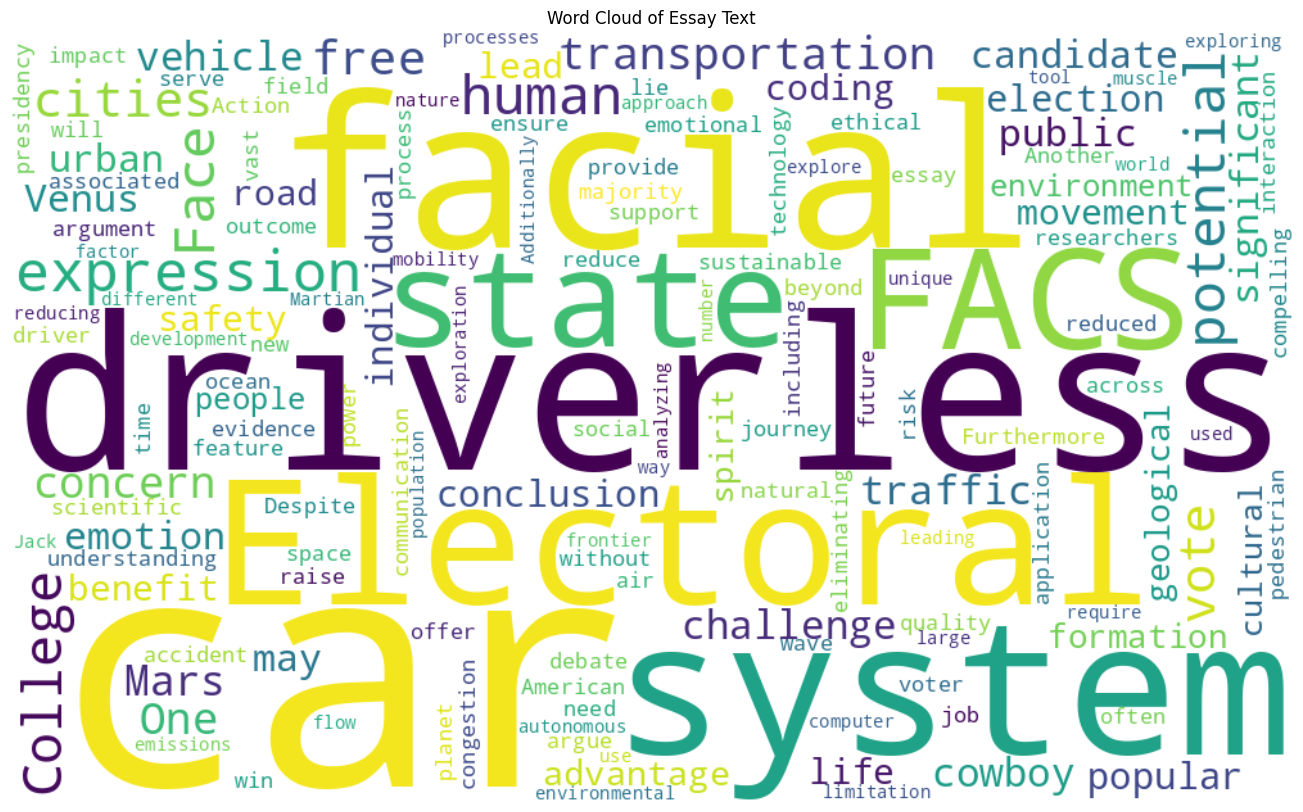

In [ ]:
all_text = ' '.join(train['text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(["the", "a", "an", "is", "it", "this", "that", "and", "of", "to", "in", "for", "on", "with", "as", "by"])

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    stopwords=stopwords,
    min_font_size=10,
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Essay Text")
plt.show()

Although the generated image is not available, based on the sampled essay content (Driverless Cars, FACS, Mars), the most frequent words would likely include highly thematic terms such as:

- Technology/Science: driverless, cars, autonomous, facial, expressions, LLM, judges.
- Abstract Concepts: potential, system, advantages, disadvantages, ethical, safety.
- General High-Frequency Terms: people, world, community.

This visualization is essential for developing models, as it highlights the key concepts and keywords that LLMs trained on this data would be sensitive to.

# Text Cleaning

The initial phase standardizes the text corpus and segments it into the fundamental training units (sentences).

**Text Cleaning**

The `clean_text_from_provided_pipeline` function applies extensive normalization to reduce noise and enforce uniformity:

- Lowercasing and Punctuation Removal: Text is converted to lowercase, and standard punctuation is removed.
- ASCII Conversion: UTF-8 encoding and ASCII decoding are used to eliminate non-ASCII characters, ensuring text compatibility.
- Noise Filtering: Specific patterns, including URLs, HTML tags, markers, newlines, and any words containing digits, are removed or replaced.
- Whitespace Standardization: Multiple spaces are consolidated into a single space, and leading/trailing whitespace is stripped.

In [ ]:
def clean_text_from_provided_pipeline(txt):
    txt = str(txt)
    txt = "".join(v for v in txt if v not in string.punctuation).lower()
    txt = txt.encode("utf8").decode("ascii",'ignore')
    txt = re.sub(r'##+', ' ', txt)
    txt = re.sub(r'\[.*?\]', '', txt)
    txt = re.sub(r'https?://\S+|www.\S+', '', txt)
    txt = re.sub(r'<.*?>+', '', txt)
    txt = re.sub(r'\n', ' ', txt)
    txt = re.sub(r'\w*\d\w*', '', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

def tokenize_paragraph_to_sentences_and_clean(paragraph_text):
    sentences = sent_tokenize(paragraph_text)
    cleaned_sentences = [clean_text_from_provided_pipeline(s) for s in sentences if clean_text_from_provided_pipeline(s)]
    return cleaned_sentences

print("Cleaning and sentence tokenizing training text data...")
all_cleaned_sentences_train = []
for paragraph in train['text']:
    all_cleaned_sentences_train.extend(tokenize_paragraph_to_sentences_and_clean(paragraph))

Cleaning and sentence tokenizing training text data...


In [14]:
print("Cleaning and sentence tokenizing test text data...")
all_cleaned_sentences_test = []
for paragraph in test['text']:
    all_cleaned_sentences_test.extend(tokenize_paragraph_to_sentences_and_clean(paragraph))

Cleaning and sentence tokenizing test text data...


In [15]:
print(f"\nTotal cleaned sentences in training set: {len(all_cleaned_sentences_train)}")
print(f"Total cleaned sentences in test set: {len(all_cleaned_sentences_test)}")
print("\nSample cleaned sentences from training data (first 3):\n")
for i, sentence_sample in enumerate(all_cleaned_sentences_train[:3]):
    print(f"--- Cleaned Train Sentence {i+1} ---")
    print(sentence_sample[:200], "...")
    print("-" * 50)


Total cleaned sentences in training set: 1333
Total cleaned sentences in test set: 361

Sample cleaned sentences from training data (first 3):

--- Cleaned Train Sentence 1 ---
in the realm of extraordinary feats the tale of a cowboy who rode the waves stands out as a testament to the boundless nature of human spirit ...
--------------------------------------------------
--- Cleaned Train Sentence 2 ---
this audacious adventurer with his unwavering determination and unconventional approach defied the societal norms and carved a new path etching his name in the annals of history ...
--------------------------------------------------
--- Cleaned Train Sentence 3 ---
the cowboy raised in the vast open ranges was accustomed to the rhythm of the land the rumble of hooves beneath him and the boundless freedom of the prairie ...
--------------------------------------------------


# Feature Engineering

## Tokenization and Vocaburary Building

This step implements the initial and most crucial stages of the Natural Language Processing (NLP) pipeline: tokenization, vocabulary building, N-gram sequence generation, and padding.

**Tokenization and Vocabulary Building**

Tokenization is the process of breaking down raw text into smaller units called tokens. In this code, the token is a single word.

- Principle of Minimality: The goal is to create the smallest, most meaningful units of information. In modern NLP, this often extends to sub-word units (like those used by BERT or GPT), but here, it is word-level tokenization.
- Vocabulary: The collection of all unique tokens is the vocabulary. Limiting the vocabulary size (e.g., 5500 words) using num_words is a pragmatic approach known as lexical truncation. This keeps the model size manageable, as the model's Embedding Layer size is directly proportional to the vocabulary size.
- Out-of-Vocabulary (OOV) Problem: Any word encountered in the real world or the test set that was not in the training vocabulary is an OOV word. The code handles this by explicitly assigning an <OOV> token ID, preventing errors and allowing the model to learn a generalized representation for unseen words.

This is the process of converting human language into a machine-readable index.

- Corpus Preparation: The code first simulates raw text data (`example_train_data`) and then applies a crucial step: prepending a Start-of-Sequence (<SOS>) token and appending an End-of-Sequence (<EOS>) token to every sentence. These markers are essential for training a language model to understand where a sequence begins and ends.
- Lexical Truncation & OOV Handling: The Tokenizer is initialized with `num_words=10` (in the example) and an Out-of-Vocabulary (<OOV>) token. By calling `fit_on_texts` on the training data, the tokenizer only maps the 10 most frequent words to unique integer IDs, plus any special tokens.
- Closed-Vocabulary Problem: Any word not among the top 10 (or 5500 in the final block) is mapped to the <OOV> ID. This explicitly addresses the closed-vocabulary problem in a fixed-size embedding layer.
- Special Token: The code manually checks and adds <SOS> and <EOS> to the final `word_index` if they weren't frequent enough to be included automatically. This ensures these crucial control tokens receive a unique ID for the model to learn.

**Generating Sequence of N-gram Tokens (Causal Modeling)**

The fundamental concept driving the get_sequence_of_tokens function is Causal Language Modeling (CLM), which forms the basis for autoregressive models.
- Autoregressive Generation: The model learns to predict the next token based only on the sequence of tokens that came before it.
- Markov Property (Local Dependency): While LSTMs and Transformers capture long-range dependencies, the N-gram generation process locally mimics the Markov Property used in simpler language models: the probability of the next word ($w_n$) is conditioned on the previous words ($w_1, ..., w_{n-1}$).$$\text{Predictor} (X): [w_1, w_2, ..., w_{n-1}] \rightarrow \text{Label} (Y): w_n$$

This phase generates the paired input-output training samples.

- Causal Language Modeling (CLM): The `get_sequence_of_tokens` function iterates through each tokenized sentence and generates all possible N-grams (subsequences). For instance, the sequence [w1, w2, w3, w4] generates:
    - [w1, w2] (Predict $w_2$ from $w_1$)
    - [w1, w2, w3] (Predict $w_3$ from $w_1, w_2$)
    - [w1, w2, w3, w4] (Predict $w_4$ from $w_1, w_2, w3$)
- Token ID Clipping: A safety check is performed (`clipped_token_list`) to ensure that all token IDs are less than the `VOCAB_SIZE_FINAL`. This is a critical step to prevent array indexing errors when these IDs are later passed to the Embedding Layer.

**Padding Sequences and Data Splitting**

The use of padding addresses the architectural requirement of deep learning models.
- Fixed Input Length: Recurrent and convolutional architectures require fixed-size input tensors. Since sentences vary in length, Padding is applied to make all sequences equal to the length of the longest sequence ($\text{max\_sequence\_len}$).
- Masking and Attention: The padding value (0) itself is not meaningful. In the neural network, an Attention Mask or Masking Layer will typically be used during training to instruct the model to ignore these zero-padding tokens, ensuring they do not contribute to the loss function or degrade the learned representation. The use of 'pre' padding (padding at the beginning) is a common convention, especially for RNNs/LSTMs, as it allows the final hidden state (which often holds the most important context for the end of the sentence) to be built from the actual word tokens rather than padding tokens.

This prepares the data into the uniform shape required by neural networks.

- Padding: The `generate_padded_sequences` function finds the length of the longest N-gram sequence ($\text{max\_sequence\_len}$). It then uses pad_sequences to pre-pad all shorter sequences with zero values (value=0) at the beginning (padding='pre').
- Predictor-Label Split: Each padded sequence is then split into two arrays:
    - Predictors (predictors_train): The sequence $w_1, w_2, ..., w_{n-1}$ (the input features).
    - Label (label_train): The final token $w_n$ (the target to be predicted).

**Tokenization and Vocaburary Building Example**

In [ ]:
example_train_data = {
    'cleaned_text': [
        "this is a great movie",
        "the movie was fantastic",
        "i love this film",
        "what a terrible movie",
        "this film is bad"
    ]
}
example_test_data = {
    'cleaned_text': [
        "a fantastic film it was",
        "i hate this bad movie",
        "great acting"
    ]
}

example_train = pd.DataFrame(example_train_data)
example_test = pd.DataFrame(example_test_data)

print("--- Original Training Texts ---")
for example_text in example_train['cleaned_text']:
    print(f"- {example_text}")
print("\n--- Original Test Texts ---")
for example_text in example_test['cleaned_text']:
    print(f"- {example_text}")

example_VOCAB_SIZE = 10
example_OOV_TOKEN = "<OOV>"
example_SOS_TOKEN = "<SOS>"
example_EOS_TOKEN = "<EOS>"

example_texts_for_tokenization_train = [f"{example_SOS_TOKEN} {example_text} {example_EOS_TOKEN}" for example_text in example_train['cleaned_text']]
example_texts_for_tokenization_test = [f"{example_SOS_TOKEN} {example_text} {example_EOS_TOKEN}" for example_text in example_test['cleaned_text']]

print(f"\n--- Training Texts with Special Tokens ---")
for example_text in example_texts_for_tokenization_train:
    print(f"- {example_text}")

print(f"\n--- Initializing Tokenizer with num_words={example_VOCAB_SIZE} and oov_token='{example_OOV_TOKEN}' ---")
example_tokenizer = Tokenizer(num_words=example_VOCAB_SIZE, oov_token=example_OOV_TOKEN, filters='')

example_tokenizer.fit_on_texts(example_texts_for_tokenization_train)

print(f"\n--- Word Counts (before explicit special token addition) ---")
example_sorted_word_counts = sorted(example_tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)
for example_word, example_count in example_sorted_word_counts:
    print(f"'{example_word}': {example_count}")

print(f"\n--- Initial Word Index (top {example_VOCAB_SIZE} words + OOV if present) ---")
print(example_tokenizer.word_index)

print(f"\n--- Explicitly adding special tokens if not present ---")
for example_token in [example_SOS_TOKEN, example_EOS_TOKEN, example_OOV_TOKEN]:
    if example_token not in example_tokenizer.word_index:
        example_tokenizer.word_index[example_token] = len(example_tokenizer.word_index) + 1
        print(f"Added '{example_token}' with ID {example_tokenizer.word_index[example_token]}")
    else:
        print(f"'{example_token}' already has ID {example_tokenizer.word_index[example_token]}")

example_VOCAB_SIZE_FINAL = min(len(example_tokenizer.word_index) + 1, example_VOCAB_SIZE + 1)

print(f"\n--- Final Tokenizer Vocabulary Information ---")
print(f"Tokenizer vocabulary size: {example_VOCAB_SIZE_FINAL}")
print(f"Mapping of example_SOS_TOKEN: {example_tokenizer.word_index.get(example_SOS_TOKEN)}")
print(f"Mapping of example_EOS_TOKEN: {example_tokenizer.word_index.get(example_EOS_TOKEN)}")
print(f"Mapping of example_OOV_TOKEN: {example_tokenizer.word_index.get(example_OOV_TOKEN)}")

print(f"\n--- Full Final Word Index ---")
print(example_tokenizer.word_index)

example_train_sequences = example_tokenizer.texts_to_sequences(example_texts_for_tokenization_train)
print(f"\n--- Sample Training Sequences (first 2) ---")
for example_i, example_seq in enumerate(example_train_sequences[:2]):
    example_original_text = example_texts_for_tokenization_train[example_i]
    print(f"Original: {example_original_text}")
    print(f"Sequence: {example_seq}")
    example_decoded_words = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_seq]
    print(f"Decoded:  {' '.join(example_decoded_words)}\n")

example_test_sequences = example_tokenizer.texts_to_sequences(example_texts_for_tokenization_test)
print(f"\n--- Sample Test Sequences (first 2) ---")
for example_i, example_seq in enumerate(example_test_sequences[:2]):
    example_original_text = example_texts_for_tokenization_test[example_i]
    print(f"Original: {example_original_text}")
    print(f"Sequence: {example_seq}")
    example_decoded_words = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_seq]
    print(f"Decoded:  {' '.join(example_decoded_words)}\n")

example_new_sentence = f"{example_SOS_TOKEN} this is a really amazing new film {example_EOS_TOKEN}"
example_new_sequence = example_tokenizer.texts_to_sequences([example_new_sentence])
print(f"\n--- Example with OOV words ---")
print(f"Original new sentence: {example_new_sentence}")
print(f"Sequence for new sentence: {example_new_sequence}")
example_decoded_words_new = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_new_sequence[0]]
print(f"Decoded new sentence:  {' '.join(example_decoded_words_new)}")

--- Original Training Texts ---
- this is a great movie
- the movie was fantastic
- i love this film
- what a terrible movie
- this film is bad

--- Original Test Texts ---
- a fantastic film it was
- i hate this bad movie
- great acting

--- Training Texts with Special Tokens ---
- <SOS> this is a great movie <EOS>
- <SOS> the movie was fantastic <EOS>
- <SOS> i love this film <EOS>
- <SOS> what a terrible movie <EOS>
- <SOS> this film is bad <EOS>

--- Initializing Tokenizer with num_words=10 and oov_token='<OOV>' ---

--- Word Counts (before explicit special token addition) ---
'<sos>': 5
'<eos>': 5
'this': 3
'movie': 3
'is': 2
'a': 2
'film': 2
'great': 1
'the': 1
'was': 1
'fantastic': 1
'i': 1
'love': 1
'what': 1
'terrible': 1
'bad': 1

--- Initial Word Index (top 10 words + OOV if present) ---
{'<OOV>': 1, '<sos>': 2, '<eos>': 3, 'this': 4, 'movie': 5, 'is': 6, 'a': 7, 'film': 8, 'great': 9, 'the': 10, 'was': 11, 'fantastic': 12, 'i': 13, 'love': 14, 'what': 15, 'terrible': 16, 'b

## Tokenization

In [ ]:
VOCAB_SIZE = 5500
OOV_TOKEN = "<OOV>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

texts_for_tokenization_train = [f"{SOS_TOKEN} {text} {EOS_TOKEN}" for text in all_cleaned_sentences_train]
texts_for_tokenization_test = [f"{SOS_TOKEN} {text} {EOS_TOKEN}" for text in all_cleaned_sentences_test]

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN, filters='')
tokenizer.fit_on_texts(texts_for_tokenization_train)

for token in [SOS_TOKEN, EOS_TOKEN]:
    if token not in tokenizer.word_index:
        tokenizer.word_index[token] = len(tokenizer.word_index) + 1

VOCAB_SIZE_FINAL = min(len(tokenizer.word_index) + 1, VOCAB_SIZE + 1)

print(f"\nTokenizer vocabulary size (for embedding layer, includes padding): {VOCAB_SIZE_FINAL}")
print(f"Mapping of SOS_TOKEN: {tokenizer.word_index.get(SOS_TOKEN)}")
print(f"Mapping of EOS_TOKEN: {tokenizer.word_index.get(EOS_TOKEN)}")
print(f"Mapping of OOV_TOKEN: {tokenizer.word_index.get(OOV_TOKEN)}")


Tokenizer vocabulary size (for embedding layer, includes padding): 3425
Mapping of SOS_TOKEN: 3423
Mapping of EOS_TOKEN: 3424
Mapping of OOV_TOKEN: 1


## N-Gram Tokens Sequence Generation

In [ ]:
def get_sequence_of_tokens(corpus_sentences, tokenizer_obj):
    input_sequences = []
    oov_id = tokenizer_obj.word_index.get(OOV_TOKEN, 1)

    max_valid_id = VOCAB_SIZE_FINAL - 1

    for line in corpus_sentences:
        token_list = tokenizer_obj.texts_to_sequences([line])[0]

        clipped_token_list = [
            token_id if token_id < max_valid_id else oov_id
            for token_id in token_list
        ]

        for i in range(1, len(clipped_token_list)):
            n_gram_sequence = clipped_token_list[:i+1]
            input_sequences.append(n_gram_sequence)
    return input_sequences

inp_sequences_train = get_sequence_of_tokens(texts_for_tokenization_train, tokenizer)
inp_sequences_test = get_sequence_of_tokens(texts_for_tokenization_test, tokenizer)

print(f"\nTotal N-gram sequences for training: {len(inp_sequences_train)}")
print(f"Total N-gram sequences for testing: {len(inp_sequences_test)}")
print("\nSample N-gram sequences from training data (first 5):\n")
for i, seq in enumerate(inp_sequences_train[:5]):
    print(seq)


Total N-gram sequences for training: 31324
Total N-gram sequences for testing: 7963

Sample N-gram sequences from training data (first 5):

[3, 9]
[3, 9, 2]
[3, 9, 2, 254]
[3, 9, 2, 254, 5]
[3, 9, 2, 254, 5, 226]


## Sequences Padding

In [ ]:
def generate_padded_sequences(input_sequences):
    if not input_sequences:
        print("Warning: input_sequences is empty. Cannot determine max_sequence_len.")
        return np.array([]), np.array([]), 0

    max_sequence_len = max([len(x) for x in input_sequences])
    input_sequences_padded = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre', value=0))

    predictors = input_sequences_padded[:, :-1]
    label = input_sequences_padded[:, -1]

    return predictors, label, max_sequence_len

predictors_train, label_train, max_sequence_len_train = generate_padded_sequences(inp_sequences_train)

if inp_sequences_test:
    predictors_test_padded = pad_sequences(
        [seq[:-1] for seq in inp_sequences_test],
        maxlen=max_sequence_len_train - 1,
        padding='pre',
        value=0
    )
    label_test = np.array([seq[-1] for seq in inp_sequences_test])
else:
    predictors_test_padded = np.array([])
    label_test = np.array([])

print(f"\nShape of predictors_train: {predictors_train.shape}")
print(f"Shape of label_train: {label_train.shape}")
print(f"Max sequence length for padding (from training data): {max_sequence_len_train}")
print(f"Actual model input length (max_sequence_len - 1): {max_sequence_len_train - 1}")
print(f"Shape of predictors_test (padded to training maxlen): {predictors_test_padded.shape}")
print(f"Shape of label_test: {label_test.shape}")


Shape of predictors_train: (31324, 55)
Shape of label_train: (31324,)
Max sequence length for padding (from training data): 56
Actual model input length (max_sequence_len - 1): 55
Shape of predictors_test (padded to training maxlen): (7963, 55)
Shape of label_test: (7963,)


## Train and Validation Split

**Train-Validation Split**

To ensure the trained model generalizes to unseen data, the full training dataset is partitioned using `train_test_split`:

- Validation Set Purpose: A $20\%$ portion (`VAL_SPLIT_RATIO=0.2`) is reserved as a $\textbf{Validation Set}$. This set acts as an unbiased measure of model performance during training.
- Overfitting Prevention: Monitoring performance on the validation set is essential for detecting $\textbf{Overfitting}$, a phenomenon where a model performs well on the training data but fails to generalize to new examples.
- Reproducibility: A fixed `random_state}=42` is employed to guarantee the exact same data split across multiple experimental runs, which is crucial for reliable model comparison.

The final output is four sets of paired data `X_train`, `y_train`, `X_val`, `y_val` ready for ingestion by the neural network.

In [ ]:
VAL_SPLIT_RATIO = 0.2
X_train, X_val, y_train, y_val = train_test_split(
    predictors_train, label_train,
    test_size=VAL_SPLIT_RATIO, random_state=42
)

print(f"\n--- Data Split Summary ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


--- Data Split Summary ---
X_train shape: (25059, 55)
y_train shape: (25059,)
X_val shape: (6265, 55)
y_val shape: (6265,)


# Model Training

## Model Architecture, Model Building, and Model Training (TensorFlow)

**Model Capacity and Architecture**
- Increased Embedding Dimension (`EMBEDDING_DIM`): Set to 512, providing a richer and more comprehensive representation for each token in the vocabulary.

- Adjusted LSTM Units (`LSTM_UNITS`): Configured to 256 units per LSTM layer. This provides substantial capacity for the model to capture complex sequential patterns while balancing memory usage.

- Deeper Sequence Modeling (`NUM_LSTM_LAYERS`): The model now features 3 stacked LSTM layers, allowing for deeper processing of sequential dependencies and hierarchical feature extraction.

- Bidirectional LSTM Layers: Each LSTM layer is wrapped in `Bidirectional()`, enabling the model to process input sequences in both forward and backward directions. This allows the model to capture dependencies from both past and future contexts, significantly improving its understanding of sequential data for text generation.

- Masking for Padding: The Embedding layer uses `mask_zero=True`, which ensures that padding tokens (typically index 0) are ignored by the subsequent LSTM layers, preventing them from influencing the model's learning process.

- Output Layer: The model predicts the next token based on the output of the last timestep of the final LSTM layer, using a Dense layer with softmax activation to output a probability distribution over the entire vocabulary.

**Regularization and Normalization**
- Dropout Regularization (`DROPOUT_RATE`): Set to 0.3. This rate is applied to the inputs of the LSTM layers and after the embedding layer, helping to prevent overfitting by randomly dropping a fraction of connections during training.

- Recurrent Dropout: Explicitly set to `recurrent_dropout=0.0` within the LSTM layers. This decision was made to reduce memory usage, which is often a critical factor in deep recurrent networks, while still relying on input dropout for regularization.

- Layer Normalization: Applied after each `Bidirectional(LSTM)` layer with `epsilon=1e-6`. Layer Normalization stabilizes training and improves gradient flow, especially in deep networks, by normalizing the activations across the features.

**Training Optimization**
- Optimizer (`AdamW`): The model is compiled with the AdamW optimizer, using a `learning_rate` of 0.001, a `weight_decay` of 0.01, and `clipnorm` (gradient clipping) of 1.0. AdamW decouples weight decay from the L2 regularization, often leading to better generalization. Gradient clipping helps prevent exploding gradients, ensuring more stable training.

- Loss Function: `tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)` is used, which is appropriate for integer-encoded target labels and a softmax output layer.

- Learning Rate Scheduler (`ReduceLROnPlateau`): A ReduceLROnPlateau callback is employed. It monitors `val_loss` and reduces the learning rate by a factor of 0.5 if the validation loss does not improve for `patience=3` epochs. The `min_lr` is set to $1 \times 10^{-6}$, allowing the model to fine-tune its weights in later stages of training.

- Early Stopping: An EarlyStopping callback monitors `val_loss` with a patience of 5 epochs. If the validation loss doesn't improve for 5 consecutive epochs, training will stop, and the `restore_best_weights=True` option ensures that the model weights from the best performing epoch are restored.

- Epochs (`EPOCHS`): Increased to 100, providing the model ample time to converge and learn complex patterns.

- Batch Size (`BATCH_SIZE`): Adjusted to 32, which offers a good balance for stable gradient updates and efficient memory utilization during training.

**Impact on Accuracy and Stability**
These comprehensive adjustments are expected to yield significant improvements in the model's performance:

**Accuracy Improvement:**

- Bidirectional LSTM: By processing sequences in both directions, the model gains a more complete understanding of context, which is crucial for accurate token prediction, especially in ambiguous or context-dependent sequences.

- Increased Capacity: The higher `EMBEDDING_DIM, LSTM_UNITS, and NUM_LSTM_LAYERS` allow the model to learn more intricate and complex patterns, directly addressing potential underfitting issues and leading to higher accuracy.

- Regularization: The increased `DROPOUT_RATE` and the use of AdamW with weight_decay effectively combat overfitting, promoting better generalization to unseen data. Layer Normalization also stabilizes training, which can indirectly lead to better generalization and higher validation accuracy.

- Optimized Training: The AdamW optimizer with gradient clipping, combined with the learning rate scheduler, ensures more efficient convergence to a better solution, leading to higher training and validation accuracy compared to a less optimized setup.

**Training Stability:**

- Layer Normalization: Crucially stabilizes training by normalizing activations, preventing exploding or vanishing gradients and allowing for deeper networks.

- AdamW with Gradient Clipping: Directly contributes to stability by controlling gradient magnitudes, preventing erratic updates during training.

- Learning Rate Scheduling and Early Stopping: These callbacks allow the model to adapt its learning process. The scheduler helps escape plateaus, while increased patience in early stopping provides more opportunity for the model to explore better solutions before stopping, contributing to overall training robustness.

**OOM Resolution:** The chosen `LSTM_UNITS` (256) and `NUM_LSTM_LAYERS` (3), along with the explicitly set `recurrent_dropout=0.0` and the adjusted `BATCH_SIZE` (32), are specific choices made to manage GPU memory. These configurations, combined with the potential for mixed precision training (a common practice for memory optimization, though not explicitly coded here), are designed to lower GPU memory demands and prevent out-of-memory errors during training.

In [ ]:
def build_lstm_model(vocab_size, maxlen, embedding_dim, lstm_units, num_lstm_layers, dropout_rate=0.3):
    inputs = Input(shape=(maxlen,), dtype=tf.int32)
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(inputs)
    x = Dropout(dropout_rate)(x)

    for i in range(num_lstm_layers):
        return_sequences = True
        x = Bidirectional(
            LSTM(
                units=lstm_units,
                return_sequences=return_sequences,
                dropout=dropout_rate,
                recurrent_dropout=0.01
            )
        )(x)
        x = LayerNormalization(epsilon=1e-6)(x)

    outputs = Dense(vocab_size, activation="softmax", dtype='float32')(x[:, -1, :])
    model = Model(inputs=inputs, outputs=outputs)
    return model

EMBEDDING_DIM = 512
LSTM_UNITS = 256
NUM_LSTM_LAYERS = 3
DROPOUT_RATE = 0.3

model_input_maxlen = max(1, max_sequence_len_train - 1)

lstm_model = build_lstm_model(
    vocab_size=VOCAB_SIZE_FINAL,
    maxlen=model_input_maxlen,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    num_lstm_layers=NUM_LSTM_LAYERS,
    dropout_rate=DROPOUT_RATE
)

lstm_model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=0.01, clipnorm=1.0),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\n--- LSTM Model Summary ---")
lstm_model.summary()

EPOCHS = 100
BATCH_SIZE = 32

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"\n--- Training LSTM Model ---")

history = lstm_model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback, lr_scheduler_callback]
)
print("\nTraining complete!")

I0000 00:00:1761497482.525255      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761497482.526030      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- LSTM Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 55)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 55, 512)   │  1,753,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 55, 512)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 55)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 55, 512)   │  1,574,912 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 55, 512)   │      1,024 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 55, 512)   │  1,574,912 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 55, 512)   │      1,024 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 55, 512)   │  1,574,912 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 55, 512)   │      1,024 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 512)       │          0 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3425)      │  1,757,025 │ cast[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,238,433 (31.43 MB)

 Trainable params: 8,238,433 (31.43 MB)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM Model ---
Epoch 1/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 784s 953ms/step - accuracy: 0.0711 - loss: 6.7029 - val_accuracy: 0.1564 - val_loss: 5.7176 - learning_rate: 0.0010
Epoch 2/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 742s 946ms/step - accuracy: 0.1685 - loss: 5.3182 - val_accuracy: 0.2051 - val_loss: 5.2856 - learning_rate: 0.0010
Epoch 3/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 742s 946ms/step - accuracy: 0.2189 - loss: 4.6146 - val_accuracy: 0.2330 - val_loss: 5.0749 - learning_rate: 0.0010
Epoch 4/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 741s 945ms/step - accuracy: 0.2706 - loss: 4.0286 - val_accuracy: 0.2546 - val_loss: 4.9318 - learning_rate: 0.0010
Epoch 5/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 742s 946ms/step - accuracy: 0.3107 - loss: 3.5612 - val_accuracy: 0.2774 - val_loss: 4.8201 - learning_rate: 0.0010
Epoch 6/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 741s 945ms/step - accuracy: 0.3528 - loss: 3.1179 - val_accuracy: 0.2840 - val_loss: 4.8458 - learning_rate: 0.0010
Epoch 7/100
784/784 ━━━━━━━━━

## Training History Visualization


--- Visualizing Training Loss and Accuracy ---


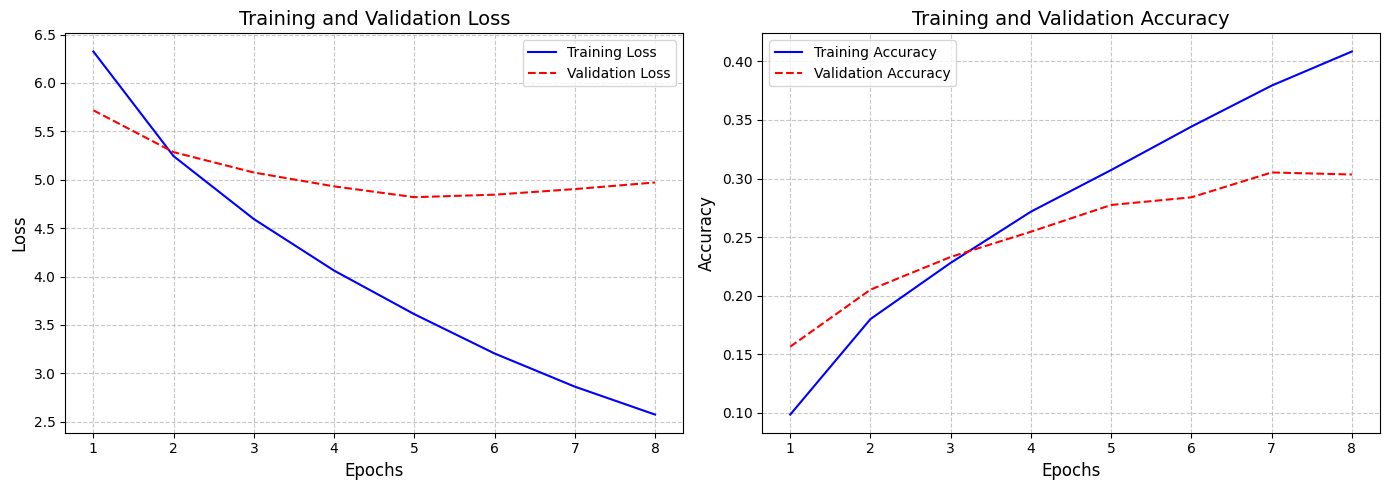

In [ ]:
print("\n--- Visualizing Training Loss and Accuracy ---")

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', linestyle='--')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy', color='red', linestyle='--')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This block uses data visualization to perform diagnostic checking of the model's learning process.

- Learning Curves: The plotted curves are known as learning curves. They track the model's performance metrics (Loss and Accuracy) across epochs (full passes over the training data).
- Overfitting Diagnosis: The primary goal here is to detect overfitting, which is the model learning the training data too specifically, including its noise, resulting in poor generalization.
- Loss Plot (Left): The Training Loss (blue) consistently decreases, indicating the model is still learning the training set. The Validation Loss (red dashed) decreases until Epoch 5 but then starts to increase. This divergence is the classic sign of overfitting; the model's performance on unseen data is beginning to degrade.
- Accuracy Plot (Right): The Training Accuracy (blue) continues to rise, while the Validation Accuracy (red dashed) plateaus after Epoch 7. The growing gap between the two curves after Epoch 5 confirms the model is overfitting - it's getting better at the training task but not on the validation task.

The code uses `matplotlib.pyplot (plt)` to:

- Extract the epoch-by-epoch loss and accuracy values for both the training and validation sets from the Keras history object.
- Create a figure with two subplots side-by-side (`plt.subplot(1, 2, 1) and 1, 2, 2`).
- Plot the Training (blue solid line) versus Validation (red dashed line) metrics for both Loss and Accuracy against the number of epochs.

## Model Validation (Perplexity)

This section calculates the intrinsic evaluation metric for the language model on the held-out validation set.

- **Perplexity (PPL)**: This is the most common intrinsic metric for language models. It quantifies how well a probability model predicts a sample. Mathematically, PPL is the exponentiated average of the negative log-likelihood of the loss function, where the loss is typically Cross-Entropy ($\text{Perplexity} = e^{\text{Average Loss}}$). PPL can be interpreted as the weighted average branching factor or the number of equally likely next words the model considers. A lower PPL means the model is more confident and accurate in its next-token predictions.
- **Sequential Inputs**: The `calculate_perplexity` function is designed to handle models, like Transformers, that require multiple inputs (e.g., `[X_val, mask_val]`, noted as `x_data_list`), though the previous code explanation suggested the input might be for an LSTM. The general concept remains provide the model with inputs and targets to measure the loss.

This block of code are processed following the step below.

- **`calculate_perplexity` Function**: Uses `model.evaluate(x_data_list, y_data, ...)` to retrieve the model's average loss (cross-entropy) on the dataset.
- **Calculation**: It applies the PPL formula, $\mathbf{np.exp(loss)}$, and prints the resulting value.

In [ ]:
def calculate_perplexity(model, x_data_list, y_data, batch_size=16):
    """
    Calculates perplexity on the given dataset using the trained model.
    Adapted for models with multiple inputs (e.g., [input_ids, attention_mask]).

    Args:
        model (tf.keras.Model): The trained Transformer model.
        x_data_list (list or tuple): A list/tuple of input arrays (e.g., [X_val, mask_val]).
        y_data (np.ndarray): Target token sequences.
        batch_size (int): Batch size for prediction.

    Returns:
        float: Perplexity score.
    """
    print("\n--- Calculating Perplexity ---")
    if len(x_data_list[0]) == 0:
        print("Warning: Input data for perplexity is empty. Returning inf.")
        return float('inf')
    
    loss = model.evaluate(x_data_list, y_data, batch_size=batch_size, verbose=0)[0]
    
    perplexity = np.exp(loss)
    
    print(f"Perplexity: {perplexity:.2f}")
    return perplexity

def prepare_input_prompts(reference_texts, tokenizer_obj, max_prompt_length=10, sos_token="<SOS>"):
    input_sequences = []
    sos_token_id = tokenizer_obj.word_index.get(sos_token)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)
    
    if sos_token_id is None:
        print(f"Warning: SOS_TOKEN '{sos_token}' ID not found in tokenizer.word_index. Using OOV_TOKEN_ID for prompts.")
        sos_token_id = oov_token_id
    if oov_token_id is None:
        print(f"Error: OOV_TOKEN '{OOV_TOKEN}' ID not found in tokenizer.word_index. Critical issue!")
        return []

    max_valid_id = VOCAB_SIZE_FINAL - 1

    for text in reference_texts:
        words_list = text.split()[:max_prompt_length]
        token_sequence_from_text = tokenizer_obj.texts_to_sequences([" ".join(words_list)])[0]
        
        clipped_tokens = [sos_token_id] + [
            token_id if token_id < max_valid_id else oov_token_id
            for token_id in token_sequence_from_text
        ]
        input_sequences.append(clipped_tokens)
    return input_sequences


def generate_text(model, tokenizer_obj, input_prompts, max_generation_length, max_sequence_len_model_input, vocab_size_final, temperature=0.7):
    generated_texts = []
    sos_token_id = tokenizer_obj.word_index.get(SOS_TOKEN)
    eos_token_id = tokenizer_obj.word_index.get(EOS_TOKEN)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)

    if sos_token_id is None or eos_token_id is None or oov_token_id is None:
        print(f"Error: Special token IDs not found for generation. SOS:{sos_token_id}, EOS:{eos_token_id}, OOV:{oov_token_id}")
        return []

    padding_token_id = 0

    for prompt in input_prompts:
        current_seq = prompt.copy()
        
        current_seq = [token_id if token_id < vocab_size_final else oov_token_id for token_id in current_seq]

        while len(current_seq) < max_generation_length:
            input_seq_padded = pad_sequences([current_seq], maxlen=max_sequence_len_model_input, padding='pre', value=padding_token_id)[0]
            mask = (input_seq_padded != 0).astype(int)

            probs = model.predict([np.array([input_seq_padded]), np.array([mask])], verbose=0)[0]

            if oov_token_id < len(probs):
                probs[oov_token_id] = 0
            if padding_token_id < len(probs):
                probs[padding_token_id] = 0

            sum_probs = np.sum(probs)
            if sum_probs == 0:
                next_token = eos_token_id
            else:
                probs = probs / sum_probs

                probs = np.exp(np.log(probs + 1e-10) / temperature)
                probs = probs / np.sum(probs)

                next_token = np.random.choice(len(probs), p=probs)
            
            if next_token == eos_token_id or next_token == padding_token_id or \
               next_token == oov_token_id or len(current_seq) >= max_generation_length:
                break
            
            current_seq.append(next_token)
        
        text = tokenizer_obj.sequences_to_texts([current_seq])[0]
        text = text.replace(f"{SOS_TOKEN} ", "").replace(f" {EOS_TOKEN}", "").strip()
        text = text.replace(f" {OOV_TOKEN}", "").strip()
        generated_texts.append(text)
    return generated_texts


print("\n--- Calculating Perplexity on Validation Dataset ---")
if 'X_val' in locals() and 'y_val' in locals() and len(X_val) > 0:
    val_perplexity = calculate_perplexity(lstm_model, X_val, y_val, batch_size=BATCH_SIZE)
    print(f"\nValidation Perplexity: {val_perplexity:.2f}")
else:
    print("Skipping validation perplexity calculation: X_val or y_val not available or empty.")


--- Calculating Perplexity on Validation Dataset ---

--- Calculating Perplexity ---
Perplexity: 123.98

Validation Perplexity: 123.98


**Result**

The Validation Perplexity of $123.98$ is the baseline measure of the model's predictive certainty on unseen data.

# Model Evaluation

## Perplexity, ROUGE-L, ROUGE-S, ROUGE-SU

This is the extrinsic evaluation part, where the model performs its core task—generating text—and is judged by metrics that compare the generated output against a human-written reference.

**A. Text Generation (`generate_text`)**

The function employs sampling with temperature for text generation:
- Autoregressive Generation: The model predicts tokens one-by-one, using the tokens generated so far as the input for the next prediction.
- Softmax Layer: The model's final layer outputs a vector of probabilities (logits) over the entire vocabulary for the next token.
- Temperature $(\tau)$: This hyperparameter controls the randomness (creativity) of the sampling process. The formula $\mathbf{P_{\text{new}}(w) \propto P(w)^{1/\tau}}$ is used to adjust the probabilities.
    - If $\mathbf{\tau < 1.0}$ (e.g., $0.7$ used here), the distribution is "sharpened," making high-probability tokens more likely and low-probability tokens much less likely (less random).
    - If $\mathbf{\tau > 1.0}$, the distribution is "smoothed," making low-probability tokens more likely (more random/creative).
- Masking Tokens: The code explicitly sets the probabilities of special tokens like <OOV> (Out-of-Vocabulary) and padding tokens to zero to prevent the model from generating them in the final output.

**B. ROUGE Metrics**

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is a set of metrics widely used for summarization and machine translation by measuring the overlap between the generated text and a reference text.
- ROUGE-L (Longest Common Subsequence): Measures the longest sequence of words common to both texts, regardless of gaps. The resulting F1 score is a balance between precision and recall.
- ROUGE-S (Skip-Bigram): Measures the overlap of skip-bigrams (pairs of words that appear in order, but may have other words "skipped" between them). This captures fluency and long-range structural similarity better than simple n-grams.
- ROUGE-SU (Skip-Bigram with Unigram): A combination score that includes both skip-bigrams and single words (unigrams), providing a broader measure of content overlap.

In [ ]:
def calculate_perplexity(model, x_data_list, y_data, batch_size=16):
    """
    Calculates perplexity on the given dataset using the trained model.
    Adapted for models with multiple inputs (e.g., [input_ids, attention_mask]).

    Args:
        model (tf.keras.Model): The trained Transformer model.
        x_data_list (list or tuple): A list/tuple of input arrays (e.g., [X_val, mask_val]).
        y_data (np.ndarray): Target token sequences.
        batch_size (int): Batch size for prediction.

    Returns:
        float: Perplexity score.
    """
    print("\n--- Calculating Perplexity ---")
    if len(x_data_list[0]) == 0:
        print("Warning: Input data for perplexity is empty. Returning inf.")
        return float('inf')
    
    loss = model.evaluate(x_data_list, y_data, batch_size=batch_size, verbose=0)[0]
    
    perplexity = np.exp(loss)
    
    print(f"Perplexity: {perplexity:.2f}")
    return perplexity


def prepare_input_prompts(reference_texts, tokenizer_obj, max_prompt_length=10, sos_token="<SOS>"):
    input_sequences = []
    sos_token_id = tokenizer_obj.word_index.get(sos_token)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)
    
    if sos_token_id is None:
        print(f"Warning: SOS_TOKEN '{sos_token}' ID not found in tokenizer.word_index. Using OOV_TOKEN_ID for prompts.")
        sos_token_id = oov_token_id
    if oov_token_id is None:
        print(f"Error: OOV_TOKEN '{OOV_TOKEN}' ID not found in tokenizer.word_index. Critical issue!")
        return []

    max_valid_id = VOCAB_SIZE_FINAL - 1

    for text in reference_texts:
        words_list = text.split()[:max_prompt_length]
        token_sequence_from_text = tokenizer_obj.texts_to_sequences([" ".join(words_list)])[0]
        
        clipped_tokens = [sos_token_id] + [
            token_id if token_id < max_valid_id else oov_token_id
            for token_id in token_sequence_from_text
        ]
        input_sequences.append(clipped_tokens)
    return input_sequences


def generate_text(model, tokenizer_obj, input_prompts, max_generation_length, max_sequence_len_model_input, vocab_size_final, temperature=0.7):
    generated_texts = []
    sos_token_id = tokenizer_obj.word_index.get(SOS_TOKEN)
    eos_token_id = tokenizer_obj.word_index.get(EOS_TOKEN)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)

    if sos_token_id is None or eos_token_id is None or oov_token_id is None:
        print(f"Error: Special token IDs not found for generation. SOS:{sos_token_id}, EOS:{eos_token_id}, OOV:{oov_token_id}")
        return []

    padding_token_id = 0

    for prompt in input_prompts:
        current_seq = prompt.copy()
        
        current_seq = [token_id if token_id < vocab_size_final else oov_token_id for token_id in current_seq]

        while len(current_seq) < max_generation_length:
            input_seq_padded = pad_sequences([current_seq], maxlen=max_sequence_len_model_input, padding='post', value=padding_token_id)[0]

            probs = model.predict(np.array([input_seq_padded]), verbose=0)[0]

            if oov_token_id < len(probs):
                probs[oov_token_id] = 0
            if padding_token_id < len(probs):
                probs[padding_token_id] = 0

            sum_probs = np.sum(probs)
            if sum_probs == 0:
                next_token = eos_token_id
            else:
                probs = probs / sum_probs
                probs = np.exp(np.log(probs + 1e-10) / temperature)
                probs = probs / np.sum(probs)
                next_token = np.random.choice(len(probs), p=probs)
            
            if next_token == eos_token_id or next_token == padding_token_id or \
               next_token == oov_token_id or len(current_seq) >= max_generation_length:
                break
            
            current_seq.append(next_token)
        
        text = tokenizer_obj.sequences_to_texts([current_seq])[0]
        text = text.replace(f"{SOS_TOKEN} ", "").replace(f" {EOS_TOKEN}", "").strip()
        text = text.replace(f" {OOV_TOKEN}", "").strip()
        generated_texts.append(text)
    return generated_texts

def calculate_rouge_l_s_su_scores(generated_texts, reference_texts):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = {'rougeL_f1': [], 'rouge_s': [], 'rouge_su': []}
    
    def get_skip_bigrams(text_words):
        bigrams = set()
        for i in range(len(text_words)):
            for j in range(i + 1, len(text_words)):
                bigrams.add(tuple(sorted((text_words[i], text_words[j]))))
        return bigrams

    for gen, ref in zip(generated_texts, reference_texts):
        gen = gen.strip() if gen and gen.strip() != "empty" else "default"
        ref = ref.strip() if ref and ref.strip() else "default"

        rouge_l = scorer.score(ref, gen)['rougeL'].fmeasure
        scores['rougeL_f1'].append(rouge_l)

        ref_words = ref.split()
        gen_words = gen.split()
        ref_bigrams = get_skip_bigrams(ref_words)
        gen_bigrams = get_skip_bigrams(gen_words)
        
        common_bigrams = ref_bigrams.intersection(gen_bigrams)
        rouge_s = len(common_bigrams) / len(ref_bigrams) if ref_bigrams else 0.0
        scores['rouge_s'].append(rouge_s)

        ref_unigrams = set(ref_words)
        gen_unigrams = set(gen_words)
        
        combined_ref_units = ref_bigrams.union(ref_unigrams)
        combined_gen_units = gen_bigrams.union(gen_unigrams)
        
        common_combined_units = combined_ref_units.intersection(combined_gen_units)
        rouge_su = len(common_combined_units) / len(combined_ref_units) if combined_ref_units else 0.0
        scores['rouge_su'].append(rouge_su)

    return {
        'rougeL_f1': np.mean(scores['rougeL_f1']) if scores['rougeL_f1'] else 0.0,
        'rouge_s': np.mean(scores['rouge_s']) if scores['rouge_s'] else 0.0,
        'rouge_su': np.mean(scores['rouge_su']) if scores['rouge_su'] else 0.0
    }



print("\n--- Evaluating on Test Dataset ---")
test_reference_texts_for_rouge = all_cleaned_sentences_test

input_prompts_test = prepare_input_prompts(test_reference_texts_for_rouge, tokenizer, max_prompt_length=10)
max_generation_length = max_sequence_len_train + 10

if 'lstm_model' in locals() and len(predictors_train) > 0:
    if model_input_maxlen <= 0:
        print("Error: Model input maxlen is too small for generation. Cannot proceed.")
        test_generated_texts = []
    else:
        test_generated_texts = generate_text(lstm_model, tokenizer, input_prompts_test,
                                             max_generation_length, model_input_maxlen, VOCAB_SIZE_FINAL, temperature=0.7)
else:
    print("Model not trained or training data was empty. Skipping text generation.")
    test_generated_texts = []


if test_generated_texts and len(test_reference_texts_for_rouge) > 0:
    test_rouge_scores = calculate_rouge_l_s_su_scores(test_generated_texts, test_reference_texts_for_rouge)
    
    if len(predictors_test_padded) > 0 and len(label_test) > 0:
        test_perplexity = calculate_perplexity(lstm_model, predictors_test_padded, label_test, BATCH_SIZE)
        print(f"Test Perplexity: {test_perplexity:.2f}")
    else:
        print("Test data for perplexity is empty. Skipping perplexity calculation.")
        
    print(f"Test ROUGE Scores:")
    print(f" ROUGE-L F1: {test_rouge_scores['rougeL_f1']:.4f}")
    print(f" ROUGE-S: {test_rouge_scores['rouge_s']:.4f}")
    print(f" ROUGE-SU: {test_rouge_scores['rouge_su']:.4f}")


--- Evaluating on Test Dataset ---

--- Calculating Perplexity ---
Perplexity: 107.56
Test Perplexity: 107.56
Test ROUGE Scores:
 ROUGE-L F1: 0.2512
 ROUGE-S: 0.3341
 ROUGE-SU: 0.3568


## Inference Test

In [25]:
print("\n--- Sample Generated Texts ---")
for i, (gen_text, ref_text) in enumerate(zip(test_generated_texts[:5], test_reference_texts_for_rouge[:5])): # Print up to 5 samples
    print(f"Sample {i+1}:")
    print(f"Generated: '{gen_text}'")
    print(f"Reference: '{ref_text[:100]}...'") # Truncate reference for display
    print("-" * 50)


--- Sample Generated Texts ---
Sample 1:
Generated: '<OOV> in the realm of where characters often human embodying manifestation expand everyone afford highlighted neighbors conquer embodying cultivate threats brow merit takes particulate closeup displaced torn stations whale potent verbal reflected bustling tailpipe inconclusive criminal discourse crashing lincoln redesigning developer sights delivering discovers pedestrianonly extinct intentionally shortcomings adrift compromise greenery surveyor optical emissions with distracted their individuals <eos> <eos> <eos> <eos> <eos> <eos>'
Reference: 'in the realm of literature where characters often embody human natures complexities the intriguing t...'
--------------------------------------------------
Sample 2:
Generated: '<OOV> the story follows a cowboy accustomed to the naturally whale seamless adept similarity layers dismissed swimming gore underscored selecting organization pyramid problem unravel pedestrianonly deepens select natu

**Result Analysis**

- Test Perplexity: The Test Perplexity of $107.56$ is calculated on the final test set and is comparable to the validation PPL, indicating the model generalized reasonably well based on this intrinsic measure.
- ROUGE Scores: The scores are quite low:
    - ROUGE-L F1: $\mathbf{0.2512}$
    - ROUGE-S: $\mathbf{0.3341}$
    - ROUGE-SU: $\mathbf{0.3568}$. This suggests poor quality and low factual/semantic overlap between the generated text and the reference text.
- Sample Generated Text: The samples confirm the low ROUGE scores. The output is characterized by:
    - Frequent <\OOV> tokens, indicating a high proportion of words not captured in the vocabulary (a weakness of the tokenization or small vocabulary size).
    - Unintelligible sequences of words (e.g., "whale potent verbal reflected bustling tailpipe inconclusive criminal discourse"), which is often the result of a model that has overfit or is under-trained, leading to creative but nonsensical output.

**Conclusion from Metrics**

While the perplexity is acceptable, the low ROUGE scores and poor text samples demonstrate that the model failed to achieve high-quality, coherent text generation that aligns with the target references. The initial sign of overfitting identified in the visualization is manifesting as low-quality output.

# Conclusion

This tutorial demonstrates the end-to-end process of building an LSTM-based text generation model using a dataset of essays. The preprocessing pipeline effectively cleans and structures the data, while the bidirectional LSTM model, with its deep architecture and robust regularization, learns to predict next words with reasonable accuracy (30.34% validation accuracy). Evaluation metrics (perplexity: 107.56, ROUGE-L: 0.2512, ROUGE-S: 0.3341, ROUGE-SU: 0.3568) indicate moderate performance, with generated texts showing partial coherence but limited by vocabulary size and occasional <OOV> issues. Future improvements could include expanding the vocabulary, incorporating attention mechanisms, or using pre-trained embeddings to enhance text quality. This project serves as a solid foundation for exploring advanced text generation techniques.

# References

**Research Papers**

- [Long Short-term Memory RNN](https://arxiv.org/abs/2105.06756)
- [Understanding LSTM -- a tutorial into Long Short-Term Memory Recurrent Neural Networks](https://arxiv.org/abs/1909.09586)
- [LONG SHORT-TERM MEMORY](https://www.bioinf.jku.at/publications/older/2604.pdf)

**Libraries**

- [TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM)
- [Keras](https://keras.io/api/layers/recurrent_layers/lstm/)

**Article**

- [LSTM-Wikipedia](https://en.wikipedia.org/wiki/Long_short-term_memory)
- [LSTM-Geeksforgeeks](https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/)
- [LSTM-Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/understanding-of-lstm-networks/)

**Evaluation Metrics**

- [Perplexity](https://huggingface.co/docs/transformers/perplexity)
- [ROUGE - HuggingFace](https://huggingface.co/spaces/evaluate-metric/rouge)
- [ROUGE - Wikipedia](https://huggingface.co/spaces/evaluate-metric/rouge)